# Analisis ABC (Pareto) Produk

Analisis ABC bertujuan untuk mengidentifikasi produk (buku) yang menjadi prioritas utama bagi bisnis berdasarkan kontribusi pendapatan mereka.

**Alur Kerja:**
1.  **Part 1: Data Loading & Preparation** - Menggabungkan semua file Excel dan membersihkan data transaksi.
2.  **Part 2: Perhitungan ABC** - Menghitung pendapatan total per produk dan mengelompokkannya ke Kategori A, B, dan C.
3.  **Part 3: Analisis & Visualisasi Cluster** - enganalisis ringkasan setiap kategori dan membuat visualisasi.
4.  **Part 4: Interpretasi & Simpan Hasil** - Memberi makna pada setiap segmen dan menyimpan hasil analisis.

## Part 1: Data Loading & Preparation

In [3]:
# Libraries untuk data
import pandas as pd
import glob
import os
from IPython.display import display
import datetime as dt
import numpy as np

# Libraries untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur agar semua kolom ditampilkan
pd.set_option('display.max_columns', None)
print("Libraries imported successfully!")

Libraries imported successfully!


**Load and Merge Transaction Data**
Kode ini akan mencari semua file Excel di folder `../dataset/`, membacanya, dan menggabungkannya menjadi satu DataFrame

In [7]:
!pip install openpyxl

path_ke_dataset = '../dataset/*.xlsx'
file_paths = glob.glob(path_ke_dataset)

if not file_paths:
    print("Tidak ada file Excel (.xlsx) yang ditemukan di folder ../dataset/.")
else:
    print(f"Ditemukan {len(file_paths)} file untuk digabungkan:")
    
    list_of_dataframes = []
    for path in file_paths:
        try:
            print(f"- Membaca {os.path.basename(path)}...")
            df = pd.read_excel(path, skiprows=4)
            list_of_dataframes.append(df)
        except Exception as e:
            print(f"Error saat membaca file {path}: {e}")

    # Gabungkan semua dataframe
    if list_of_dataframes: # Pastikan list tidak kosong sebelum menggabung
        df_merged = pd.concat(list_of_dataframes, ignore_index=True)
        print("Semua file berhasil digabungkan.")
        print(f"Total baris data setelah digabung: {len(df_merged)}")
        display(df_merged.head())
    else:
        print("Gagal memuat semua file, tidak ada data untuk digabungkan.")

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Ditemukan 8 file untuk digabungkan:
- Membaca Penjualan 2017.xlsx...
- Membaca Penjualan 2018.xlsx...
- Membaca Penjualan 2019.xlsx...
- Membaca Penjualan 2020.xlsx...
- Membaca Penjualan 2021.xlsx...
- Membaca Penjualan 2022.xlsx...
- Membaca Penjualan 2023.xlsx...
- Membaca Penjualan 2024.xlsx...
Semua file berhasil digabungkan.
Total baris data setelah digabung: 71012


,No.,Tgl. Trans.,No. Trans.,Syarat Bayar.,Tgl. Jatuh Tempo,Customer,Total (Rp),PPN (Rp),Biaya Kirim (Rp),Grand Total (Rp),No. SO,No. Konsinyasi,ISBN,ISBN Dtl.,Judul,Satuan,Jml,Harga (Rp),Total Disc (%),Total Disc (Rp),Subtotal (Rp),Catatan,Ekspedisi,No. Resi,Tgl. Kirim
0,1,2017-01-03,J.01.1701.0001,CASH,2017-01-03,YUNICA FITRIANI,30000.0,0.0,0.0,30000.0,NaN,NaN,9786021302217,9786021302217.099609,SOUL KEEPING (MENJAGA JIWA),EX,1.0,60000.0,50.0,30000.0,30000.0,NaN,NaN,NaN,NaN
1,2,2017-01-03,J.01.1701.0002,CASH,2017-01-03,MELINA,124000.0,0.0,0.0,124000.0,NaN,NaN,9786021854754,9786021854754.099609,BAHAN PA : MENCARI KEHENDAK TUHAN,EX,1.0,24000.0,NaN,0.0,24000.0,NaN,NaN,NaN,NaN
2,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9786021854716,9786021854716.099609,JUST DO SOMETHING (LAKUKANLAH SESUATU),EX,1.0,40000.0,NaN,0.0,40000.0,NaN,NaN,NaN,NaN
3,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9766029670097,9766029670097.099609,MEMBENTUK KEROHANIAN ANAK MUDA,EX,1.0,60000.0,NaN,0.0,60000.0,NaN,NaN,NaN,NaN
4,3,2017-01-03,J.01.1701.0003,7 HARI,2017-01-10,IWAN SATRIA,400000.0,0.0,45000.0,445000.0,NaN,NaN,9786021854761,9786021854761.099609,UANG DAN PEKERJAAN,EX,20.0,25000.0,20.0,5000.0,400000.0,NaN,NaN,NaN,NaN


### Data Cleaning and Preparation
Untuk Analisis ABC, hanya dibutuhkan dua kolom utama, yaitu Judul Produk dan Total Belanja.

In [8]:
KOLOM_JUDUL = 'Judul'
KOLOM_TOTAL_BELANJA = 'Subtotal (Rp)'

# 1. Pilih kolom yang dibutuhkan dan bersihkan data
df_abc_prep = df_merged[[KOLOM_JUDUL, KOLOM_TOTAL_BELANJA]].copy()

# 2. Bersihkan data
# Hapus baris di mana Judul tidak ada (NaN)
df_abc_prep.dropna(subset=[KOLOM_JUDUL], inplace=True)

# Ubah Total Belanja menjadi numerik, ganti error/NaN dengan 0
df_abc_prep[KOLOM_TOTAL_BELANJA] = pd.to_numeric(df_abc_prep[KOLOM_TOTAL_BELANJA], errors='coerce').fillna(0)

# 3. Filter data yang tidak relevan (sama seperti di RFM, buang yang belanjanya 0 atau negatif)
df_abc_prep = df_abc_prep[df_abc_prep[KOLOM_TOTAL_BELANJA] > 0]

print(f"Data untuk ABC berhasil disiapkan. Ada {len(df_abc_prep)} transaksi yang valid.")
display(df_abc_prep.head())


Data untuk ABC berhasil disiapkan. Ada 69408 transaksi yang valid.


,Judul,Subtotal (Rp)
0,SOUL KEEPING (MENJAGA JIWA),30000.0
1,BAHAN PA : MENCARI KEHENDAK TUHAN,24000.0
2,JUST DO SOMETHING (LAKUKANLAH SESUATU),40000.0
3,MEMBENTUK KEROHANIAN ANAK MUDA,60000.0
4,UANG DAN PEKERJAAN,400000.0


### Part 2: ABC Calculation

Selanjutnya, kita mengagregasi data untuk mendapatkan total pendapatan per buku, lalu menghitung kategori A, B, dan C.

In [9]:
# 1. Agregasi pendapatan per buku (Judul)
df_abc = df_abc_prep.groupby(KOLOM_JUDUL)[KOLOM_TOTAL_BELANJA].sum().reset_index()
df_abc.rename(columns={KOLOM_TOTAL_BELANJA: 'Total_Revenue'}, inplace=True)

# 2. Urutkan dari pendapatan tertinggi ke terendah
df_abc = df_abc.sort_values(by='Total_Revenue', ascending=False)

# 3. Hitung total pendapatan dan persentase kumulatif
total_revenue_all = df_abc['Total_Revenue'].sum()
df_abc['Revenue_Share'] = df_abc['Total_Revenue'] / total_revenue_all
df_abc['Cumulative_Share'] = df_abc['Revenue_Share'].cumsum()

# 4. Tetapkan Kategori A, B, C
def assign_abc_category(cum_share):
    if cum_share <= 0.80:
        return 'A'  # 80% Pendapatan Teratas
    elif cum_share <= 0.95:
        return 'B'  # 15% Pendapatan Berikutnya
    else:
        return 'C'  # 5% Pendapatan Sisa

df_abc['ABC_Category'] = df_abc['Cumulative_Share'].apply(assign_abc_category)

print("✅ Perhitungan Analisis ABC selesai.")
display(df_abc.head())

✅ Perhitungan Analisis ABC selesai.


,Judul,Total_Revenue,Revenue_Share,Cumulative_Share,ABC_Category
332,THE SACRED SEARCH CU 6,5.163836e+08,0.040790,0.040790,A
220,NGBO,4.608578e+08,0.036404,0.077194,A
84,EMOTIONALLY HEALTHY SPIRITUALITY,4.201710e+08,0.033190,0.110384,A
305,THE EMOTIONALLY HEALTHY LEADER (PEMIMPIN YANG ...,3.894520e+08,0.030763,0.141147,A
206,MENGHIDUPI INJIL & MENGINJILI HIDUP,3.684715e+08,0.029106,0.170253,A


### Part 3: Analisis dan Visualisasi Cluster

##### Profil Kategori ABC
Berikut ini merupakan tabel ringkasan yang menunjukkan performa setiap kategori.

In [14]:
# Menghitung ringkasan performa untuk setiap kategori
abc_summary = df_abc.groupby('ABC_Category').agg(
    Jumlah_Judul=('Judul', 'count'),
    Total_Pendapatan=('Total_Revenue', 'sum')
)

# Hitung persentase
total_judul = abc_summary['Jumlah_Judul'].sum()
total_pendapatan = abc_summary['Total_Pendapatan'].sum()

abc_summary['Persentase_Judul'] = (abc_summary['Jumlah_Judul'] / total_judul)
abc_summary['Persentase_Pendapatan'] = (abc_summary['Total_Pendapatan'] / total_pendapatan)

# Format untuk tampilan yang lebih baik
abc_summary_display = abc_summary.copy()
abc_summary_display['Total_Pendapatan'] = abc_summary_display['Total_Pendapatan'].map('Rp {:,.2f}'.format)
abc_summary_display['Persentase_Judul'] = abc_summary_display['Persentase_Judul'].map('{:.2%}'.format)
abc_summary_display['Persentase_Pendapatan'] = abc_summary_display['Persentase_Pendapatan'].map('{:.2%}'.format)

print("--- Ringkasan Analisis ABC ---")
display(abc_summary_display)


--- Ringkasan Analisis ABC ---


,Jumlah_Judul,Total_Pendapatan,Persentase_Judul,Persentase_Pendapatan
ABC_Category,,,,
A,77,"Rp 10,087,211,404.46",20.92%,79.68%
B,54,"Rp 1,929,682,338.70",14.67%,15.24%
C,237,"Rp 642,686,100.23",64.40%,5.08%


##### Visualisasi Ringkasan ABC (Pareto Plot)

Visualisasi ini membantu kita melihat "Prinsip Pareto" (80/20) dengan jelas.

* Batang Biru: Jumlah judul buku di setiap kategori.

* Garis Merah: Persentase kontribusi pendapatan dari setiap kategori.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6280\1872065290.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


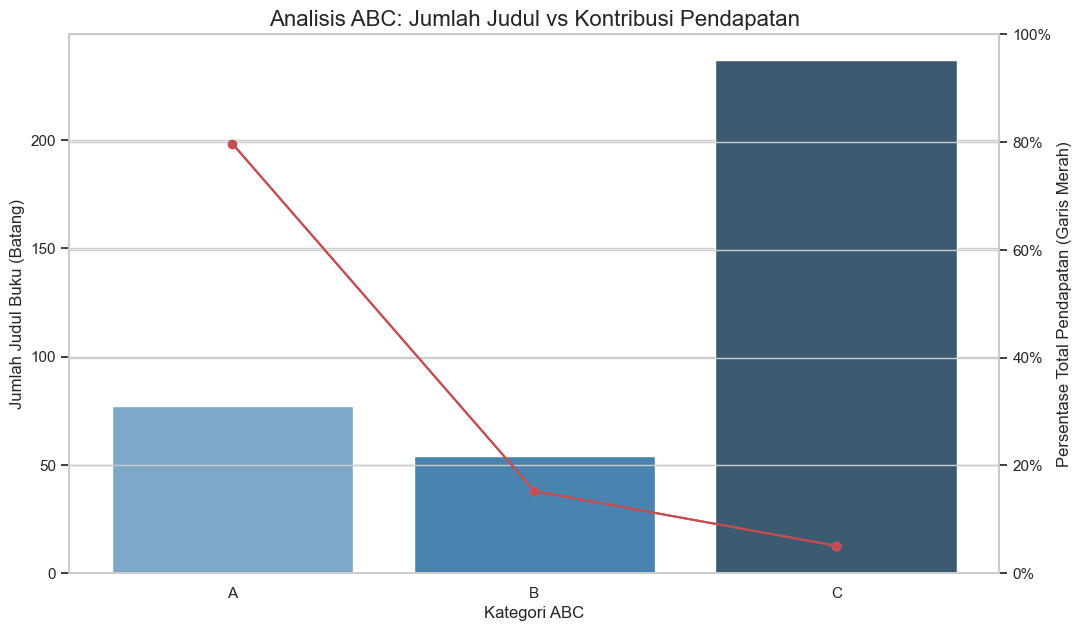

In [15]:
# Gunakan data ringkasan yang belum diformat (numerik)
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot 1: Bar plot untuk jumlah judul
sns.barplot(
    x=abc_summary.index, 
    y='Jumlah_Judul', 
    data=abc_summary, 
    ax=ax1, 
    palette="Blues_d",
    order=['A', 'B', 'C'] # Pastikan urutan benar
)
ax1.set_ylabel('Jumlah Judul Buku (Batang)')
ax1.set_xlabel('Kategori ABC')

# Buat sumbu Y kedua
ax2 = ax1.twinx()

# Plot 2: Line plot untuk persentase pendapatan
sns.lineplot(
    x=abc_summary.index, 
    y='Persentase_Pendapatan', 
    data=abc_summary, 
    ax=ax2, 
    color='r', 
    marker='o', 
    sort=False # Gunakan urutan A, B, C
)
# Pastikan data line plot diurutkan A, B, C
ax2.plot(abc_summary.index, abc_summary['Persentase_Pendapatan'], color='r', marker='o')

ax2.set_ylabel('Persentase Total Pendapatan (Garis Merah)')
ax2.set_ylim(0, 1) # Skala dari 0 sampai 1 untuk persentase
ax2.yaxis.set_major_formatter(plt.FuncFormatter('{:.0%}'.format))


plt.title('Analisis ABC: Jumlah Judul vs Kontribusi Pendapatan', fontsize=16)
plt.savefig('abc_analysis_summary_chart.png')
plt.show()


##### Distribusi Pendapatan per Kategori
Berikut ini boxplot untuk melihat sebaran pendapatan di dalam setiap kategori

showfliers=False digunakan karena Kategori A memiliki beberapa buku yang sangat mahal, yang akan membuat boxplot B dan C tidak terlihat.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6280\1945332875.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


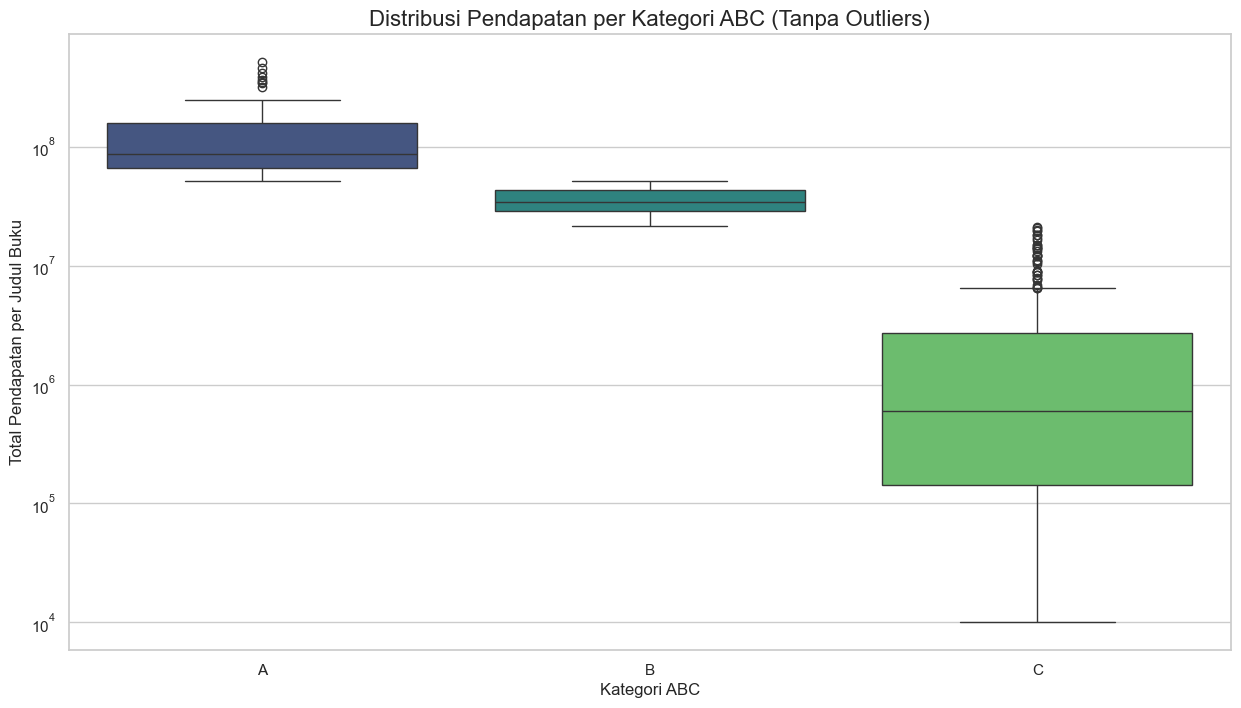

In [17]:
plt.figure(figsize=(15, 8))

# Gunakan data df_abc yang lengkap
sns.boxplot(
    x='ABC_Category', 
    y='Total_Revenue', 
    data=df_abc, 
    palette='viridis', 
    order=['A', 'B', 'C'],
    #showfliers=False # Matikan outliers agar plot lebih mudah dibaca
)

plt.title('Distribusi Pendapatan per Kategori ABC (Tanpa Outliers)', fontsize=16)
plt.xlabel('Kategori ABC', fontsize=12)
plt.ylabel('Total Pendapatan per Judul Buku', fontsize=12)
plt.yscale('log') # Gunakan skala log karena rentang data yang besar
plt.show()

### Part 4: Interpretasi dan Simpan Hasil

##### Interpretasi dan Rekomendasi Strategis

Berdasarkan data di atas, berikut adalah interpretasinya:

**Kategori A**

Deskripsi: Ini adalah buku-buku "tulang punggung" (backbone) bisnis. Jumlahnya sangat sedikit (misal: 10-15% dari total judul) tetapi menyumbang 80% dari seluruh pendapatan.

Rekomendasi Strategis:

 1. Stok **WAJIB** Ada: Anggaran stok harus diprioritaskan untuk buku-buku ini. Jangan pernah biarkan stok kosong.

 2. Marketing: Gunakan buku ini sebagai hero product dalam promosi atau bundling untuk menarik pelanggan.

**Kategori B**

Deskripsi: Ini adalah buku-buku "penjualan menengah" yang stabil. Jumlahnya sedikit lebih banyak (misal: 15-20% dari total judul) dan menyumbang 15% dari pendapatan.

Rekomendasi Strategis:

 1. Pantau Stok: Stok harus dijaga, tetapi tidak seketat Kategori A.

 2. Potensi "Naik Kelas": Analisis buku-buku ini, mungkin beberapa bisa dipromosikan untuk menjadi Kategori A.

**Kategori C**

Deskripsi: Ini adalah mayoritas judul buku Anda (misal: 70%) tetapi secara kolektif hanya menyumbang 5% dari pendapatan.

Rekomendasi Strategis:

 1. Jangan Overstock: Buku-buku ini memakan biaya gudang. Pertimbangkan model "Print on Demand" (Cetak Sesuai Pesanan) atau stok minimal.

 2. Cuci Gudang: Buku-buku di kategori ini bisa di-bundling dalam promo "Clearance Sale" untuk mengosongkan gudang dan memutar modal.

##### Simpan Hasil Analisis

Terakhir, kita simpan seluruh hasil perhitungan ABC ke file CSV untuk digunakan di laporan akhir atau Power BI.


In [18]:
# Simpan hasil lengkap ke CSV
output_filename = 'abc_analysis_results.csv'
df_abc.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"✅ Analisis ABC lengkap berhasil disimpan ke: {output_filename}")


✅ Analisis ABC lengkap berhasil disimpan ke: abc_analysis_results.csv
